findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

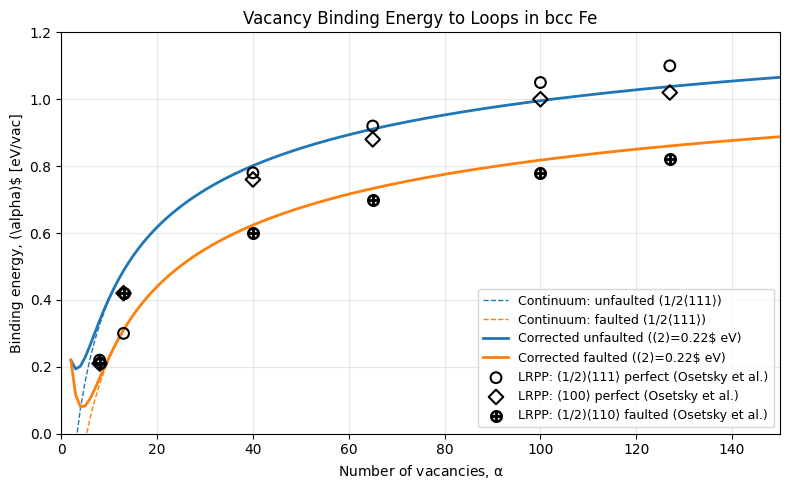

 alpha    R (nm)    Eb_unf_cont    Eb_unf_mod    Eb_flt_cont    Eb_flt_mod
    2     0.174           -0.1802            0.2200           -0.3578            0.2200
   11     0.407            0.4330            0.4353            0.2554            0.2587
   51     0.877            0.8580            0.8580            0.6804            0.6804
  101     1.235            0.9974            0.9974            0.8198            0.8198
  501     2.750            1.2255            1.2255            1.0479            1.0479
  997     3.879            1.2906            1.2906            1.1130            1.1130

Transition correction (unfaulted):
  E_b(2) atomistic  = 0.220 eV
  E_b(2) continuum  = -0.1802 eV
  Correction at alpha=2:  +0.4002 eV
  Correction at alpha=10: +0.0040 eV  (1.0% of initial)

Transition correction (faulted):
  E_b(2) continuum  = -0.3578 eV
  Correction at alpha=2:  +0.5778 eV
  Correction at alpha=10: +0.0058 eV  (1.0% of initial)
  Decay constant lambda = 0.576 vac^-1


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

mpl.rcParams["mathtext.fontset"] = "dejavusans"

PLOT_DIR = Path("../output/plots/rate_data")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Material parameters for bcc Fe
# -----------------------------
a = 2.866e-10          # lattice parameter, m
b = a * np.sqrt(3) / 2 # Burgers vector magnitude for 1/2<111>, m
Omega = a**3 / 2       # atomic volume for bcc, m^3
G = 82e9               # shear modulus, Pa
nu = 0.29              # Poisson\'s ratio
Evf = 1.5              # vacancy formation energy, eV

# Stacking fault energy (example value)
# You may change this if you want a different effective value
gamma_sf = 0.6         # J/m^2

# Joule to eV conversion
J_to_eV = 1.0 / 1.602176634e-19
r_c = b / 3           # dislocation core radius, m
# -----------------------------
# Vacancy count range (start at alpha=2 for divacancy)
# -----------------------------
alpha = np.arange(2, 1001)

# -----------------------------
# Loop radius as function of alpha
# pi R^2 b = alpha * Omega
# -----------------------------
R = np.sqrt(alpha * Omega / (np.pi * b))

# -----------------------------
# Chemical potentials (J)
# -----------------------------
mu_unfaulted_J = (
    G * b * Omega / (4 * np.pi * (1 - nu) * R)
    * (np.log(R / r_c) + 1.0)
)

mu_faulted_J = mu_unfaulted_J + gamma_sf * Omega / b

# Convert chemical potentials to eV
mu_unfaulted_eV = mu_unfaulted_J * J_to_eV
mu_faulted_eV   = mu_faulted_J   * J_to_eV

# -----------------------------
# Continuum binding energies (eV)
# E_b = E_v^f - mu_loop
# -----------------------------
Eb_unfaulted = Evf - mu_unfaulted_eV
Eb_faulted   = Evf - mu_faulted_eV

# -------------------------------------------------------
# Smooth transition correction (same method as void, cell 3)
#
# Both curves are anchored to the atomistic divacancy binding
# energy E_b(2) = 0.22 eV via an exponential correction:
#
#   E_b_mod(alpha) = E_b_cont(alpha)
#                    + [E_b(2) - E_b_cont(2)] * exp(-lambda*(alpha-2))
#
# Decay rate: correction falls to ~1% at alpha=10
#   exp(-lambda*(10-2)) = 0.01  =>  lambda = ln(100)/8
# -------------------------------------------------------
Eb_2_atom = 0.22                   # eV, atomistic divacancy binding energy
lam = np.log(100) / 8              # approx 0.575 vac^-1

# Continuum predictions at alpha=2 (first element of each array)
Eb_cont_unf_2 = Eb_unfaulted[0]
Eb_cont_flt_2 = Eb_faulted[0]

correction_unf = (Eb_2_atom - Eb_cont_unf_2) * np.exp(-lam * (alpha - 2))
correction_flt = (Eb_2_atom - Eb_cont_flt_2) * np.exp(-lam * (alpha - 2))

Eb_unfaulted_mod = Eb_unfaulted + correction_unf
Eb_faulted_mod   = Eb_faulted   + correction_flt

# -------------------------------------------------------
# Digitized LRPP data — Osetsky et al., vacancy loops in Fe
# Fig. 8: binding energy per vacancy vs. number of vacancies
# -------------------------------------------------------
# (1/2)<111> perfect vacancy loops (open circles)
lrpp_111_n  = np.array([8,    13,   40,   65,   100,  127 ])
lrpp_111_Eb = np.array([0.22, 0.30, 0.78, 0.92, 1.05, 1.10])

# <100> perfect vacancy loops (diamonds)
lrpp_100_n  = np.array([8,    13,   40,   65,   100,  127 ])
lrpp_100_Eb = np.array([0.21, 0.42, 0.76, 0.88, 1.00, 1.02])

# (1/2)<110> faulted vacancy loops (crossed circles)
lrpp_110_n  = np.array([8,    13,   40,   65,   100,  127 ])
lrpp_110_Eb = np.array([0.21, 0.42, 0.60, 0.70, 0.78, 0.82])

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Continuum model lines (dashed)
ax.plot(alpha, Eb_unfaulted, color="C0", linewidth=1, linestyle="--",
        label="Continuum: unfaulted (1/2\u27e8111\u27e9)")
ax.plot(alpha, Eb_faulted,   color="C1", linewidth=1, linestyle="--",
        label="Continuum: faulted (1/2\u27e8111\u27e9)")

# Corrected curves (solid)
ax.plot(alpha, Eb_unfaulted_mod, color="C0", linewidth=2,
        label=r"Corrected unfaulted ((2)=0.22$ eV)")
ax.plot(alpha, Eb_faulted_mod,   color="C1", linewidth=2,
        label=r"Corrected faulted ((2)=0.22$ eV)")

# LRPP atomistic data points
ax.scatter(lrpp_111_n, lrpp_111_Eb,
           marker="o", facecolors="none", edgecolors="k", s=60, linewidths=1.5,
           label="LRPP: (1/2)\u27e8111\u27e9 perfect (Osetsky et al.)", zorder=5)
ax.scatter(lrpp_100_n, lrpp_100_Eb,
           marker="D", facecolors="none", edgecolors="k", s=55, linewidths=1.5,
           label="LRPP: \u27e8100\u27e9 perfect (Osetsky et al.)", zorder=5)
ax.scatter(lrpp_110_n, lrpp_110_Eb,
           marker=r"$\oplus$", c="k", s=70,
           label="LRPP: (1/2)\u27e8110\u27e9 faulted (Osetsky et al.)", zorder=5)

ax.set_xlabel(r"Number of vacancies, $\alpha$")
ax.set_ylabel(r"Binding energy, (\alpha)$ [eV/vac]")
ax.set_title("Vacancy Binding Energy to Loops in bcc Fe")
ax.set_xlim(0, 150)
ax.set_ylim(0, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(PLOT_DIR / "binding_energy.png", dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------
# Optional: print a few values
# -----------------------------
sample_indices = [0, 9, 49, 99, 499, 995]  # representative points
print(" alpha    R (nm)    Eb_unf_cont    Eb_unf_mod    Eb_flt_cont    Eb_flt_mod")
for i in sample_indices:
    if i < len(alpha):
        print(f"{alpha[i]:5d}   {R[i]*1e9:7.3f}        {Eb_unfaulted[i]:10.4f}        {Eb_unfaulted_mod[i]:10.4f}        {Eb_faulted[i]:10.4f}        {Eb_faulted_mod[i]:10.4f}")

print(f"\nTransition correction (unfaulted):")
print(f"  E_b(2) atomistic  = {Eb_2_atom:.3f} eV")
print(f"  E_b(2) continuum  = {Eb_cont_unf_2:.4f} eV")
print(f"  Correction at alpha=2:  {correction_unf[0]:+.4f} eV")
print(f"  Correction at alpha=10: {correction_unf[8]:+.4f} eV  ({100*correction_unf[8]/correction_unf[0]:.1f}% of initial)")
print(f"\nTransition correction (faulted):")
print(f"  E_b(2) continuum  = {Eb_cont_flt_2:.4f} eV")
print(f"  Correction at alpha=2:  {correction_flt[0]:+.4f} eV")
print(f"  Correction at alpha=10: {correction_flt[8]:+.4f} eV  ({100*correction_flt[8]/correction_flt[0]:.1f}% of initial)")
print(f"  Decay constant lambda = {lam:.3f} vac^-1")


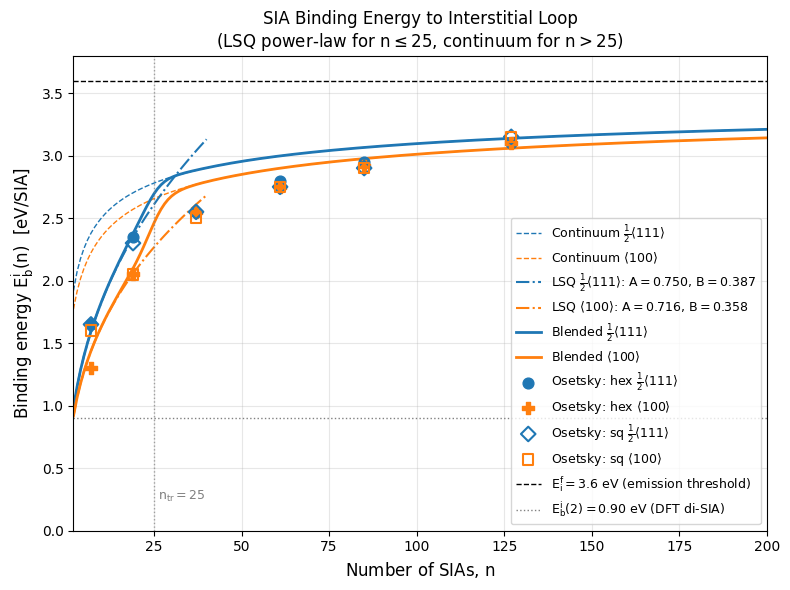

Parameters:
  E_F_i   = 3.60 eV
  b_111   = 2.4820 A,  r_c = 0.8273 A
  b_100   = 2.8660 A,  r_c = 0.9553 A

LSQ power-law fit  Eb(n) = A * n^B  (atomistic data, n <= 25):
  1/2<111>:  A = 0.7501 eV,  B = 0.3873
  <100>:     A = 0.7160 eV,  B = 0.3581

Fit residuals (eV)  [predicted - atomistic]:
  1/2<111> (n=[ 2  7  7 19 19]): [ 0.08106501 -0.05625423 -0.05625423 -0.00373644  0.04626356]
  <100>    (n=[ 2  7  7 19 19]): [ 0.01773239  0.13723564 -0.16276436  0.00496776  0.00496776]

Transition: tanh blend centred at n_tr=25.0, sigma=5.0
  w(n= 15) = 0.982  (LSQ weight)
  w(n= 20) = 0.881  (LSQ weight)
  w(n= 25) = 0.500  (LSQ weight)
  w(n= 30) = 0.119  (LSQ weight)
  w(n= 35) = 0.018  (LSQ weight)

Sample binding energies [1/2<111>]:
     n    R (nm)   Eb_cont (eV)   Eb_lsq (eV)   Eb_mod (eV)
     2     0.174         1.9198        0.9811        0.9812
     3     0.213         2.0685        1.1479        1.1480
     5     0.275         2.2579        1.3990        1.3993
     7     0.3

: 

In [ ]:
# -------------------------------------------------------
# Binding energy of a SIA to an interstitial loop
# Dislocation loop elasticity model
#
# Loop radius (circular perfect loop):
#   R(n) = sqrt(n * Omega / (pi * b_perp))
#
# Chemical potential for adding one SIA to a loop of size n:
#   mu_il(n) = G * b * Omega / (4*pi*(1-nu)*R) * (ln(R/r_c) + 1)
#
# Continuum binding energy:
#   E_b^i(n) = E_i^F - mu_il(n)
#
# For n <= 25 the continuum overestimates E_b (elastic model breaks
# down for small clusters).  We replace it with a power-law
#
#   E_b_fit(n) = A * n^B
#
# fitted by least squares to all atomistic data points with n <= 25
# (DFT di-SIA at n=2 plus Osetsky MD points at n=7 and n=19).
#
# For n > 25 we recover the continuum via a tanh blending:
#
#   w(n) = 0.5 * (1 + tanh((n_tr - n) / sigma_tr))   [1 near 0, 0 near inf]
#   E_b_mod(n) = w(n)*E_b_fit(n) + (1 - w(n))*E_b_cont(n)
#
# Burgers vectors (bcc Fe):
#   1/2<111>:  b_111 = a*sqrt(3)/2
#   <100>:     b_100 = a
#
# Parameters:
#   E_i^F = 3.6 eV   (interstitial formation energy, bcc Fe)
#   r_c   = b/3      (dislocation core cutoff radius, per loop type)
# -------------------------------------------------------
from scipy.optimize import curve_fit

# --- Parameters ---
E_F_i       = 3.6          # eV, SIA formation energy (bcc Fe)
Eb_2_atom_i = 0.90         # eV, di-SIA binding energy (DFT bcc Fe)
                            # Domain & Becquart (2001) PRB 65, 024103;
                            # Marinica et al. (2011) J. Phys.: Condens. Matter 23, 165402

# Burgers vector magnitudes
b_111 = a * np.sqrt(3) / 2   # 1/2<111>, m
b_100 = a                     # <100>,    m

# Core radii (r_c = b/3)
rc_111 = b_111 / 3
rc_100 = b_100 / 3

# --- SIA cluster size range ---
n_i = np.arange(2, 1001)

# --- Loop radii ---
R_111 = np.sqrt(n_i * Omega / (np.pi * b_111))
R_100 = np.sqrt(n_i * Omega / (np.pi * b_100))

# --- Chemical potentials (J -> eV) ---
mu_111_J  = G * b_111 * Omega / (4 * np.pi * (1 - nu) * R_111) * (np.log(R_111 / rc_111) + 1.0)
mu_100_J  = G * b_100 * Omega / (4 * np.pi * (1 - nu) * R_100) * (np.log(R_100 / rc_100) + 1.0)

mu_111_eV = mu_111_J * J_to_eV
mu_100_eV = mu_100_J * J_to_eV

# --- Continuum binding energies ---
Eb_111_cont = E_F_i - mu_111_eV
Eb_100_cont = E_F_i - mu_100_eV

# -------------------------------------------------------
# Digitized atomistic data - Osetsky et al.
# 'Stability and mobility of defect clusters and dislocation loops in metals'
# J. Nucl. Mater. 276, 65 (2000), Fig. 3
# LRPP potential, bcc Fe - binding energy per SIA vs. loop size
# -------------------------------------------------------
# Hexagonal loops
oset_hex_111_n  = np.array([7,    19,   37,   61,   85,   127  ])
oset_hex_111_Eb = np.array([1.65, 2.35, 2.55, 2.80, 2.95, 3.10 ])  # 1/2<111> {111}

oset_hex_100_n  = np.array([7,    19,   37,   61,   85,   127  ])
oset_hex_100_Eb = np.array([1.30, 2.05, 2.55, 2.75, 2.92, 3.10 ])  # <100> {100}

# Square loops
oset_sq_111_n   = np.array([7,    19,   37,   61,   85,   127  ])
oset_sq_111_Eb  = np.array([1.65, 2.30, 2.55, 2.75, 2.90, 3.15 ])  # 1/2<111> {111}

oset_sq_100_n   = np.array([7,    19,   37,   61,   85,   127  ])
oset_sq_100_Eb  = np.array([1.60, 2.05, 2.50, 2.75, 2.90, 3.15 ])  # <100> {100}

# -------------------------------------------------------
# Least-squares power-law fit to atomistic data with n <= 25
#
# Data collected per Burgers vector type:
#   1/2<111>: n=2 (DFT), n=7 (hex + sq), n=19 (hex + sq) -> 5 points
#   <100>:    n=2 (DFT), n=7 (hex + sq), n=19 (hex + sq) -> 5 points
#
# Model:  Eb_fit(n) = A * n^B
# -------------------------------------------------------
def power_law(n, A, B):
    return A * np.asarray(n, dtype=float) ** B

# 1/2<111> fit data (n <= 25)
n_fit_111  = np.array([2,    7,    7,    19,   19  ])
Eb_fit_111 = np.array([0.90, 1.65, 1.65, 2.35, 2.30])  # DFT + Osetsky hex + sq

# <100> fit data (n <= 25)
n_fit_100  = np.array([2,    7,    7,    19,   19  ])
Eb_fit_100 = np.array([0.90, 1.30, 1.60, 2.05, 2.05])  # DFT + Osetsky hex + sq

popt_111, _ = curve_fit(power_law, n_fit_111, Eb_fit_111, p0=[0.6, 0.5])
popt_100, _ = curve_fit(power_law, n_fit_100, Eb_fit_100, p0=[0.5, 0.5])

A_111, B_111 = popt_111
A_100, B_100 = popt_100

Eb_111_lsq = power_law(n_i, A_111, B_111)
Eb_100_lsq = power_law(n_i, A_100, B_100)

# -------------------------------------------------------
# Smooth transition from LSQ fit (n << 25) to continuum (n >> 25)
#
#   w(n) = 0.5 * (1 + tanh((n_tr - n) / sigma_tr))
#   Eb_mod(n) = w(n)*Eb_lsq(n) + (1 - w(n))*Eb_cont(n)
# -------------------------------------------------------
n_tr     = 25.0  # transition centre (SIAs)
sigma_tr =  5.0  # transition half-width (SIAs)

w = 0.5 * (1.0 + np.tanh((n_tr - n_i) / sigma_tr))

Eb_111_mod = w * Eb_111_lsq + (1.0 - w) * Eb_111_cont
Eb_100_mod = w * Eb_100_lsq + (1.0 - w) * Eb_100_cont

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

# Continuum curves (dashed)
ax.plot(n_i, Eb_111_cont, color='C0', linewidth=1, linestyle='--',
        label=r'Continuum $\frac{1}{2}\langle111\rangle$')
ax.plot(n_i, Eb_100_cont, color='C1', linewidth=1, linestyle='--',
        label=r'Continuum $\langle100\rangle$')

# LSQ fit (shown up to n=40 for visual clarity)
mask_fit = n_i <= 40
ax.plot(n_i[mask_fit], Eb_111_lsq[mask_fit], color='C0', linewidth=1.5, linestyle='-.',
        label=rf'LSQ $\frac{{1}}{{2}}\langle111\rangle$: $A={A_111:.3f}$, $B={B_111:.3f}$')
ax.plot(n_i[mask_fit], Eb_100_lsq[mask_fit], color='C1', linewidth=1.5, linestyle='-.',
        label=rf'LSQ $\langle100\rangle$: $A={A_100:.3f}$, $B={B_100:.3f}$')

# Blended model (solid)
ax.plot(n_i, Eb_111_mod, color='C0', linewidth=2,
        label=r'Blended $\frac{1}{2}\langle111\rangle$')
ax.plot(n_i, Eb_100_mod, color='C1', linewidth=2,
        label=r'Blended $\langle100\rangle$')

# Transition indicator
ax.axvline(n_tr, color='grey', linestyle=':', linewidth=1, alpha=0.7)
ax.text(n_tr + 1, 0.25, rf'$n_{{\mathrm{{tr}}}}={int(n_tr)}$', fontsize=9, color='grey')

# Atomistic data
ax.scatter(oset_hex_111_n, oset_hex_111_Eb, marker='o', s=60, color='C0', zorder=5,
           label=r'Osetsky: hex $\frac{1}{2}\langle111\rangle$')
ax.scatter(oset_hex_100_n, oset_hex_100_Eb, marker='P', s=70, color='C1', zorder=5,
           label=r'Osetsky: hex $\langle100\rangle$')
ax.scatter(oset_sq_111_n,  oset_sq_111_Eb,  marker='D', s=55, facecolors='none',
           edgecolors='C0', linewidths=1.5, zorder=5,
           label=r'Osetsky: sq $\frac{1}{2}\langle111\rangle$')
ax.scatter(oset_sq_100_n,  oset_sq_100_Eb,  marker='s', s=55, facecolors='none',
           edgecolors='C1', linewidths=1.5, zorder=5,
           label=r'Osetsky: sq $\langle100\rangle$')

ax.axhline(E_F_i, color='k', linestyle='--', linewidth=1,
           label=r'$E_i^f = %.1f$ eV (emission threshold)' % E_F_i)
ax.axhline(Eb_2_atom_i, color='grey', linestyle=':', linewidth=1,
           label=r'$E_b^i(2) = %.2f$ eV (DFT di-SIA)' % Eb_2_atom_i)

ax.set_xlabel(r'Number of SIAs, $n$', fontsize=12)
ax.set_ylabel(r'Binding energy $E_b^i(n)$  [eV/SIA]', fontsize=12)
ax.set_title('SIA Binding Energy to Interstitial Loop\n'
             r'(LSQ power-law for $n \leq 25$, continuum for $n > 25$)')
ax.set_xlim(2, 200)
ax.set_ylim(0, E_F_i + 0.2)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(PLOT_DIR / 'binding_energy_interstitial_loop.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print(f'Parameters:')
print(f'  E_F_i   = {E_F_i:.2f} eV')
print(f'  b_111   = {b_111*1e10:.4f} A,  r_c = {rc_111*1e10:.4f} A')
print(f'  b_100   = {b_100*1e10:.4f} A,  r_c = {rc_100*1e10:.4f} A')
print(f'\nLSQ power-law fit  Eb(n) = A * n^B  (atomistic data, n <= 25):')
print(f'  1/2<111>:  A = {A_111:.4f} eV,  B = {B_111:.4f}')
print(f'  <100>:     A = {A_100:.4f} eV,  B = {B_100:.4f}')
print(f'\nFit residuals (eV)  [predicted - atomistic]:')
res_111 = power_law(n_fit_111, A_111, B_111) - Eb_fit_111
res_100 = power_law(n_fit_100, A_100, B_100) - Eb_fit_100
print(f'  1/2<111> (n={n_fit_111}): {res_111}')
print(f'  <100>    (n={n_fit_100}): {res_100}')
print(f'\nTransition: tanh blend centred at n_tr={n_tr}, sigma={sigma_tr}')
for n_check in [15, 20, 25, 30, 35]:
    wc = 0.5 * (1.0 + np.tanh((n_tr - n_check) / sigma_tr))
    print(f'  w(n={n_check:3d}) = {wc:.3f}  (LSQ weight)')
print(f'\nSample binding energies [1/2<111>]:')
print(f'{"n":>6}  {"R (nm)":>8}  {"Eb_cont (eV)":>13}  {"Eb_lsq (eV)":>12}  {"Eb_mod (eV)":>12}')
for idx in [0, 1, 3, 5, 8, 17, 23, 35, 63, 98, 198]:
    if idx < len(n_i):
        print(f'{n_i[idx]:6d}  {R_111[idx]*1e9:8.3f}  {Eb_111_cont[idx]:13.4f}  {Eb_111_lsq[idx]:12.4f}  {Eb_111_mod[idx]:12.4f}')


<>:57: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:57: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\Owner\AppData\Local\Temp\ipykernel_5000\1151755672.py:57: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  label=r'$\omega_r = b_r G$')


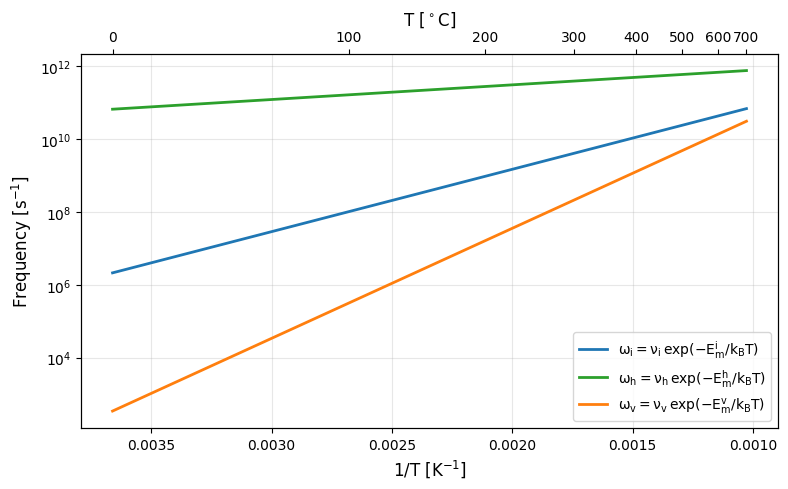

Parameters used:
  nu_i  = 4.000e+12 s^-1,  E_m_i = 0.34 eV
  nu_h  = 2.000e+12 s^-1,  E_m_h = 0.08 eV
  nu_v  = 4.000e+13 s^-1,  E_m_v = 0.6 eV
  G     = 1.000e-06 dpa/s,  b_r = 1.0


In [3]:
import pandas as pd

# -------------------------------------------------------
# Read parameters from input_parameters.xlsx
# -------------------------------------------------------
INPUT_FILE = '../../EuroferExperiments/input/input_parameters.xlsx'

def read_param(df, notation):
    """Return scalar Value for a given Notation string."""
    row = df.loc[df['Notation'].astype(str).str.strip() == notation, 'Value']
    if row.empty:
        raise KeyError(f"Parameter '{notation}' not found")
    return float(row.iloc[0])

df_env  = pd.read_excel(INPUT_FILE, sheet_name='Material_Environment')
df_phys = pd.read_excel(INPUT_FILE, sheet_name='Physical_Properties')

nu_i  = read_param(df_phys, 'nu_i')   # s^-1, interstitial attempt frequency
nu_v  = read_param(df_phys, 'nu_v')   # s^-1, vacancy attempt frequency
nu_h  = read_param(df_phys, 'nu_h')   # s^-1, helium attempt frequency
E_m_i = read_param(df_phys, 'E_m_i') # eV,   interstitial migration energy
E_m_v = read_param(df_phys, 'E_m_v') # eV,   vacancy migration energy
E_m_h = read_param(df_phys, 'E_m_h') # eV,   helium migration energy
G_dpa = read_param(df_env,  'G')      # dpa/s, dose rate
b_r   = read_param(df_phys, 'b_r')      # resolution parameter (dimensionless)

kB = 8.617333e-5  # eV K^-1

# -------------------------------------------------------
# Temperature range
# -------------------------------------------------------
T_C   = np.linspace(0, 700, 600)
T_K   = T_C + 273.15
inv_T = 1.0 / T_K

# -------------------------------------------------------
# Four basic frequencies
# -------------------------------------------------------
omega_i = nu_i * np.exp(-E_m_i / (kB * T_K))   # s^-1
omega_h = nu_h * np.exp(-E_m_h / (kB * T_K))   # s^-1
omega_v = nu_v * np.exp(-E_m_v / (kB * T_K))   # s^-1
omega_r = b_r  * G_dpa * np.ones_like(T_K)      # s^-1  (temperature-independent)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(inv_T, omega_i, color='C0', linewidth=2,
            label=r'$\omega_i = \nu_i\,\exp(-E_m^i/k_BT)$')
ax.semilogy(inv_T, omega_h, color='C2', linewidth=2,
            label=r'$\omega_h = \nu_h\,\exp(-E_m^h/k_BT)$')
ax.semilogy(inv_T, omega_v, color='C1', linewidth=2,
            label=r'$\omega_v = \nu_v\,\exp(-E_m^v/k_BT)$')
'''
ax.semilogy(inv_T, omega_r, color='C3', linewidth=2, linestyle='--',
            label=r'$\omega_r = b_r G$')
'''
ax.set_xlabel(r'$1/T$ [K$^{-1}$]', fontsize=12)
ax.set_ylabel(r'Frequency [s$^{-1}$]', fontsize=12)
ax.invert_xaxis()   # high T on left, low T on right

# Top x-axis: T in Â°C
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
T_ticks_C  = np.array([0, 100, 200, 300, 400, 500, 600, 700])
inv_T_ticks = 1.0 / (T_ticks_C + 273.15)
ax2.set_xticks(inv_T_ticks)
ax2.set_xticklabels([f'{t:.0f}' for t in T_ticks_C])
ax2.set_xlabel(r'$T$ [$^\circ$C]', fontsize=12)

ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
fig.savefig(PLOT_DIR / 'jump_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Parameters used:")
print(f"  nu_i  = {nu_i:.3e} s^-1,  E_m_i = {E_m_i} eV")
print(f"  nu_h  = {nu_h:.3e} s^-1,  E_m_h = {E_m_h} eV")
print(f"  nu_v  = {nu_v:.3e} s^-1,  E_m_v = {E_m_v} eV")
print(f"  G     = {G_dpa:.3e} dpa/s,  b_r = {b_r}")

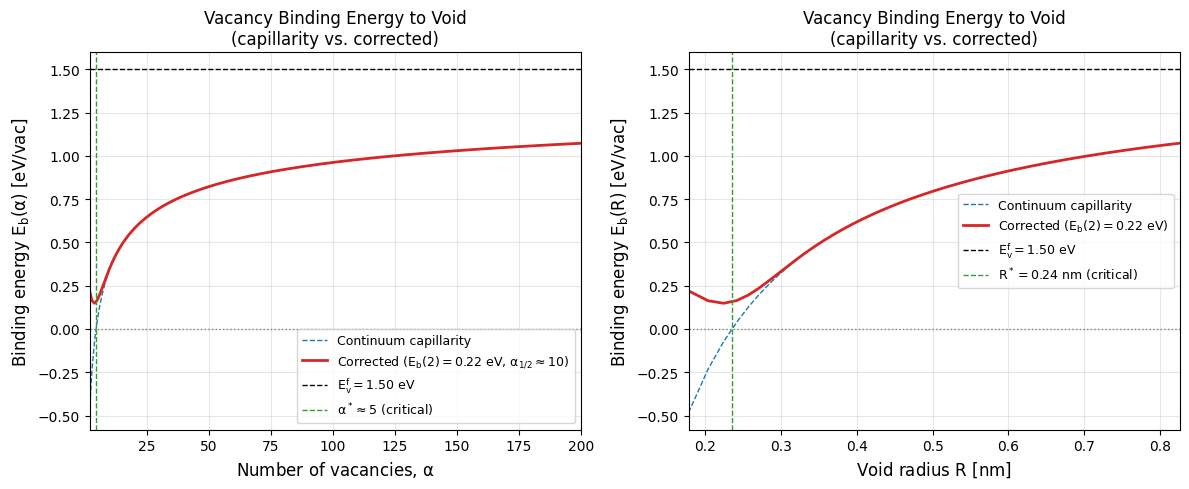

Parameters read from input_parameters.xlsx:
  E_F_v  = 1.500 eV
  gamma  = 1.498e+19 eV/mÂ²
  a      = 2.8660e-10 m,  Omega = 1.1771e-29 mÂ³

Transition correction:
  E_b(2) atomistic  = 0.220 eV
  E_b(2) continuum  = -0.4829 eV
  Correction at alpha=2:  +0.7029 eV
  Correction at alpha=10: +0.0070 eV  (1.0% of initial)
  Decay constant lambda = 0.576 vac^-1

Critical void size (E_b = 0, continuum):
  R*     = 0.235 nm
  alpha* â‰ˆ 4.6 vacancies

Sample binding energies:
 alpha    R (nm)   Eb_cont (eV)   Eb_mod (eV)
     2     0.178        -0.4829        0.2200
     3     0.204        -0.2323        0.1630
     5     0.241         0.0390        0.1640
    10     0.304         0.3404        0.3474
    20     0.383         0.5796        0.5796
    50     0.520         0.8218        0.8218
   100     0.655         0.9617        0.9617
   200     0.825         1.0728        1.0728
   500     1.120         1.1852        1.1852
  1000     1.411         1.2502        1.2502


In [4]:
# -------------------------------------------------------
# Binding energy of a vacancy to a void / He-bubble
# Capillarity model with virial-EOS gas pressure
#
# Void radius (spherical, V = alpha*Omega = 4pi R^3/3):
#   R(alpha) = a * (3*alpha / (8*pi))^(1/3)
#
# Defect chemical potential for vacancy exchange:
#   mu(alpha) = Omega * (2*gamma/R  -  P_g)
#
# Binding energy (continuum capillarity):
#   E_b(alpha) = E_v^f - mu(alpha)
#
# Modified binding energy with discrete correction:
#   E_b_mod(alpha) = E_b_cont(alpha)
#                    + [E_b(2) - E_b_cont(2)] * exp(-lambda*(alpha-2))
#   where lambda is chosen so the correction is ~1% at alpha=10.
#   This pins the dimer value at E_b(2)=0.22 eV (atomistic)
#   and smoothly asymptotes to the continuum curve by alpha~10.
# -------------------------------------------------------

# --- Read parameters from input_parameters.xlsx (df_phys loaded above) ---
E_F_v  = read_param(df_phys, 'E_F_v')   # eV       vacancy formation energy
gamma  = read_param(df_phys, 'gamma')   # eV m^-2  surface energy
B_2    = read_param(df_phys, 'B_2')     # m^3/atom  2nd virial coefficient (0 â†’ ideal gas)
B_3    = read_param(df_phys, 'B_3')     # m^6/atom^2 3rd virial coefficient

# `a` and `Omega` are defined in cell 1 (bcc: Omega = a^3/2)

# --- Vacancy cluster size range (start at alpha=2) ---
alpha_v = np.arange(2, 1001)

# --- Void radius: R = a * (3*alpha / (8*pi))^(1/3) ---
R_v = a * (3 * alpha_v / (8 * np.pi))**(1/3)

# --- Gas pressure (m = 0 â†’ void, P_g = 0) ---
m = 0
T_void = 600.0 + 273.15   # K
n_He = np.zeros_like(alpha_v, dtype=float)
P_g  = np.zeros_like(alpha_v, dtype=float)

# --- Continuum binding energy ---
mu_v   = Omega * (2 * gamma / R_v - P_g)   # eV
Eb_v   = E_F_v - mu_v                       # eV

# --- Transition-corrected binding energy ---
# Dimer binding energy (atomistic, Osetsky et al.)
Eb_2_atom = 0.22   # eV

# Continuum prediction at alpha=2
R_v2      = a * (3 * 2 / (8 * np.pi))**(1/3)
Eb_cont_2 = E_F_v - Omega * (2 * gamma / R_v2)

# Decay rate: correction falls to ~1 % at alpha=10
#   exp(-lambda * (10-2)) = 0.01  =>  lambda = ln(100)/8
lam = np.log(100) / 8   # â‰ˆ 0.575 vac^-1

correction = (Eb_2_atom - Eb_cont_2) * np.exp(-lam * (alpha_v - 2))
Eb_mod     = Eb_v + correction

# --- Critical cluster size: E_b = 0 (unstable below alpha_star) ---
R_star     = 2 * gamma * Omega / E_F_v
alpha_star = (8 * np.pi / 3) * (R_star / a)**3

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: E_b vs number of vacancies alpha
ax = axes[0]
ax.plot(alpha_v, Eb_v,   color='C0', linewidth=1, linestyle='--', label='Continuum capillarity')
ax.plot(alpha_v, Eb_mod, color='C3', linewidth=2,
        label=r'Corrected ($E_b(2)=0.22$ eV, $\alpha_{1/2}\approx10$)')
ax.axhline(E_F_v, color='k', linestyle='--', linewidth=1,
           label=r'$E_v^f = %.2f$ eV' % E_F_v)
ax.axhline(0, color='grey', linestyle=':', linewidth=1)
if 2 <= alpha_star <= alpha_v[-1]:
    ax.axvline(alpha_star, color='C2', linestyle='--', linewidth=1,
               label=r'$\alpha^* \approx %.0f$ (critical)' % alpha_star)
ax.set_xlabel(r'Number of vacancies, $\alpha$', fontsize=12)
ax.set_ylabel(r'Binding energy $E_b(\alpha)$ [eV/vac]', fontsize=12)
ax.set_title('Vacancy Binding Energy to Void\n(capillarity vs. corrected)')
ax.set_xlim(2, 200)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: E_b vs void radius R
ax = axes[1]
ax.plot(R_v * 1e9, Eb_v,   color='C0', linewidth=1, linestyle='--', label='Continuum capillarity')
ax.plot(R_v * 1e9, Eb_mod, color='C3', linewidth=2, 
        label=r'Corrected ($E_b(2)=0.22$ eV)')
ax.axhline(E_F_v, color='k', linestyle='--', linewidth=1,
           label=r'$E_v^f = %.2f$ eV' % E_F_v)
ax.axhline(0, color='grey', linestyle=':', linewidth=1)
if R_star > 0:
    ax.axvline(R_star * 1e9, color='C2', linestyle='--', linewidth=1,
               label=r'$R^* = %.2f$ nm (critical)' % (R_star * 1e9))
ax.set_xlabel(r'Void radius $R$ [nm]', fontsize=12)
ax.set_ylabel(r'Binding energy $E_b(R)$ [eV/vac]', fontsize=12)
ax.set_title('Vacancy Binding Energy to Void\n(capillarity vs. corrected)')
# xlim from R at alpha=2 to R at alpha=201
ax.set_xlim(R_v[0] * 1e9, R_v[199] * 1e9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(PLOT_DIR / 'binding_energy_void.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print(f"Parameters read from input_parameters.xlsx:")
print(f"  E_F_v  = {E_F_v:.3f} eV")
print(f"  gamma  = {gamma:.3e} eV/mÂ²")
print(f"  a      = {a:.4e} m,  Omega = {Omega:.4e} mÂ³")
print(f"\nTransition correction:")
print(f"  E_b(2) atomistic  = {Eb_2_atom:.3f} eV")
print(f"  E_b(2) continuum  = {Eb_cont_2:.4f} eV")
print(f"  Correction at alpha=2:  {correction[0]:+.4f} eV")
print(f"  Correction at alpha=10: {correction[8]:+.4f} eV  ({100*correction[8]/correction[0]:.1f}% of initial)")
print(f"  Decay constant lambda = {lam:.3f} vac^-1")
print(f"\nCritical void size (E_b = 0, continuum):")
print(f"  R*     = {R_star*1e9:.3f} nm")
print(f"  alpha* â‰ˆ {alpha_star:.1f} vacancies")
print(f"\nSample binding energies:")
print(f"{'alpha':>6}  {'R (nm)':>8}  {'Eb_cont (eV)':>13}  {'Eb_mod (eV)':>12}")
for i in [0, 1, 3, 8, 18, 48, 98, 198, 498, 998]:
    if i < len(alpha_v):
        print(f"{alpha_v[i]:6d}  {R_v[i]*1e9:8.3f}  {Eb_v[i]:13.4f}  {Eb_mod[i]:12.4f}")

He-bubble corrections at T = 600 Â°C  (k_BT = 75.2 meV):

 m/alpha   P_g (GPa)   Omega*Pg (meV)   m_ref  Eb_atom(2) (eV)   Delta_Eb (eV)
    0.01       0.0104              0.76     0.02            0.2556           0.7377
    0.10       0.1174              8.63     0.20            0.5044           0.9788
    0.60       1.4001            102.86     1.20            1.0284           1.4085

  Correction decays with lambda = 0.576 vac^-1  (~1% of initial at alpha=10)
  Langmuir m_half = 0.70  (verify against Fu & Willaime 2005, PRB 72 064117, Table I)


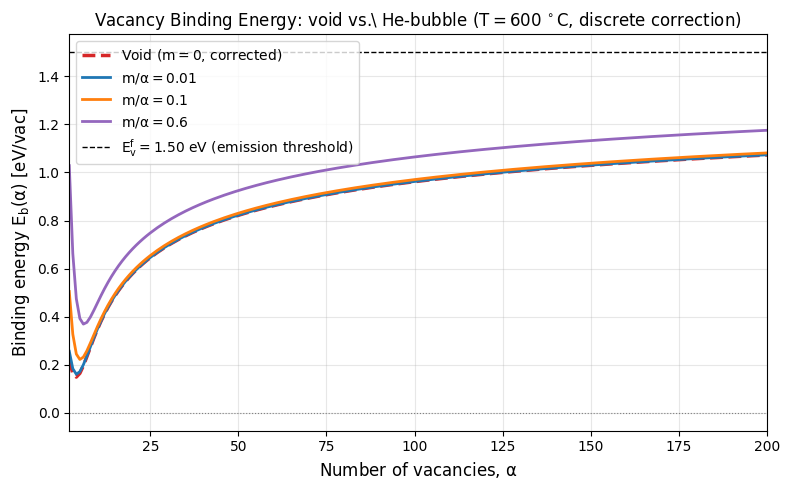

In [5]:
# -------------------------------------------------------
# Binding energy of a vacancy to a He-bubble
# Corrected void curve + corrected He-bubble curves
# for fixed He/vacancy ratios m/alpha = 0.01, 0.1, 0.6
#
# He gas pressure via virial EOS (kB in eV/K throughout):
#   n_He = (m/alpha) / Omega            [m^-3]
#   P_g  = n_He * kB * T * (1 + B2*n_He + B3*n_He^2)   [eV/m^3]
#
# Continuum binding energy:
#   Eb_cont(alpha, m) = E_F_v - Omega*(2*gamma/R(alpha) - P_g(m/alpha))
#
# Discrete correction at small alpha:
#   The continuum gas-pressure model captures He stabilisation only through
#   Omega*P_g, which is meV-scale for small clusters (see pressure printout).
#   At small alpha the dominant stabilisation is direct He-vacancy binding
#   (~1 eV per He, from DFT), not captured by the continuum EOS.
#
#   Reference atomistic values at alpha=2 from DFT/MD in bcc Fe:
#     m=0 He:  E_B^v(He0 V2) = 0.22 eV  â€” Osetsky et al. (2000), J. Nucl. Mater. 276, 65
#     m=1 He:  E_B^v(He1 V2) ~ 0.85 eV  â€” estimated from Fu & Willaime (2005), PRB 72, 064117 *
#     m=2 He:  E_B^v(He2 V2) ~ 1.30 eV  â€” estimated from Morishita et al. (2003), J. Nucl. Mater. 323, 243 *
#     m >> 1:  -> E_F_v (high-He-density limit)
#   (* estimated from DFT/MD formation-energy tables; verify against original papers)
#
#   NOTE: Becquart & Domain (2006) PRL 97, 196402 is about He in W, not Fe â€” do not cite here.
#
#   Continuous parameterisation (Langmuir-type):
#     E_B^v_atom(alpha=2, r) = E_b0 + (E_F_v - E_b0) * m_ref / (m_ref + m_half)
#   where m_ref = r * 2  (He atoms in the reference alpha=2 cluster)
#         E_b0 = 0.22 eV (pure-void dimer)
#         m_half = 0.70   (fitted to He1V2 ~ 0.85 eV; verify with Fu & Willaime 2005 Table I)
#
#   Same exponential decay as pure-void correction (continuum valid at alpha~10).
# -------------------------------------------------------

# --- Correction parameters (verify m_half against Fu & Willaime 2005 Table I) ---
Eb_2_atom_He = 0.22   # eV, He0V2 dimer (m=0) â€” Osetsky et al. (2000)
m_half_he    = 0.70   # He atoms at half-saturation (dimensionless)

def Eb_atom_alpha2(m_ref, E_b0, E_sat, m_half):
    """Atomistic E_B^v at alpha=2 vs. He count m_ref in the reference dimer cluster."""
    return E_b0 + (E_sat - E_b0) * m_ref / (m_ref + m_half)

# lam, R_v2, E_F_v, gamma, Omega carried over from previous cell

he_ratios = [0.01, 0.1, 0.6]
he_colors = ['C0', 'C1', 'C4']
he_labels = [r'$m/\alpha = 0.01$', r'$m/\alpha = 0.1$', r'$m/\alpha = 0.6$']

fig_he, ax_he = plt.subplots(figsize=(8, 5))

# --- Corrected void curve (m=0), carried over from previous cell ---
ax_he.plot(alpha_v, Eb_mod, color='C3', linewidth=2.5, linestyle='--',
           label=r'Void ($m=0$, corrected)')

# --- He-bubble curves with discrete correction ---
print(f"He-bubble corrections at T = {T_void - 273.15:.0f} Â°C  (k_BT = {kB*T_void*1e3:.1f} meV):\n")
print(f"{'m/alpha':>8}  {'P_g (GPa)':>10}  {'Omega*Pg (meV)':>15}  "
      f"{'m_ref':>6}  {'Eb_atom(2) (eV)':>15}  {'Delta_Eb (eV)':>14}")

for ratio, color, label in zip(he_ratios, he_colors, he_labels):
    n_he   = ratio / Omega
    P_g_he = n_he * kB * T_void * (1.0 + B_2 * n_he + B_3 * n_he**2)   # eV/m^3
    P_GPa  = P_g_he * 1.602176634e-19 * 1e-9                             # GPa

    # --- Continuum binding energy (alpha-dependent) ---
    mu_he_cont = Omega * (2.0 * gamma / R_v - P_g_he)
    Eb_he_cont = E_F_v - mu_he_cont

    # --- Discrete correction ---
    # Continuum value at the reference alpha=2 point
    Eb_cont_2_he = E_F_v - Omega * (2.0 * gamma / R_v2 - P_g_he)

    # Atomistic value at alpha=2 via Langmuir parameterisation
    m_ref      = ratio * 2.0                               # He atoms in alpha=2 cluster
    Eb_atom_2  = Eb_atom_alpha2(m_ref, Eb_2_atom_He, E_F_v, m_half_he)

    # Exponential correction (same lambda as pure-void)
    correction = (Eb_atom_2 - Eb_cont_2_he) * np.exp(-lam * (alpha_v - 2))
    Eb_he_mod  = Eb_he_cont + correction

    ax_he.plot(alpha_v, Eb_he_mod, color=color, linewidth=2, label=label)

    print(f"  {ratio:6.2f}   {P_GPa:10.4f}   {Omega*P_g_he*1e3:15.2f}   "
          f"{m_ref:6.2f}   {Eb_atom_2:15.4f}   {(Eb_atom_2 - Eb_cont_2_he):14.4f}")

print()
print(f"  Correction decays with lambda = {lam:.3f} vac^-1  (~1% of initial at alpha=10)")
print(f"  Langmuir m_half = {m_half_he:.2f}  (verify against Fu & Willaime 2005, PRB 72 064117, Table I)")

ax_he.axhline(E_F_v, color='k', linestyle='--', linewidth=1,
              label=r'$E_v^f = %.2f$ eV (emission threshold)' % E_F_v)
ax_he.axhline(0, color='grey', linestyle=':', linewidth=0.8)

ax_he.set_xlabel(r'Number of vacancies, $\alpha$', fontsize=12)
ax_he.set_ylabel(r'Binding energy $E_b(\alpha)$ [eV/vac]', fontsize=12)
ax_he.set_title(r'Vacancy Binding Energy: void vs.\ He-bubble'
                r'$\ (T = 600\,^\circ\mathrm{C}$, discrete correction)')
ax_he.set_xlim(2, 200)
ax_he.legend(fontsize=10)
ax_he.grid(True, alpha=0.3)
plt.tight_layout()
fig_he.savefig(PLOT_DIR / 'binding_energy_he_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

Verification â€” m=0 surface cut vs. Eb_mod (cell 3):
   alpha     Surface      Eb_mod       diff
       2      0.2200      0.2200   -1.1e-16
       3      0.1630      0.1630   -5.6e-17
       5      0.1640      0.1640   -2.8e-17
      10      0.3474      0.3474    0.0e+00
      20      0.5796      0.5796    0.0e+00
      50      0.8218      0.8218    0.0e+00
     100      0.9617      0.9617    0.0e+00
     200      1.0728      1.0728    0.0e+00

Fit residuals  (E_B^v_surface - E_B^v_data):
  (alpha,m)     data    surface     resid
  ( 2,0)       0.220      0.220    -0.000
  ( 1,1)       2.300      2.198    -0.102
  ( 2,1)       0.780      1.235     0.455
  ( 3,1)       0.830      0.731    -0.099
  ( 4,1)       1.160      0.472    -0.688
  ( 1,2)       3.710      3.790     0.080
  ( 2,2)       1.610      1.725     0.115
  ( 3,2)       1.040      0.979    -0.061
  ( 4,2)       1.320      0.613    -0.707
  ( 1,3)       4.590      5.023     0.433
  ( 2,3)       1.850      1.427    -0.423


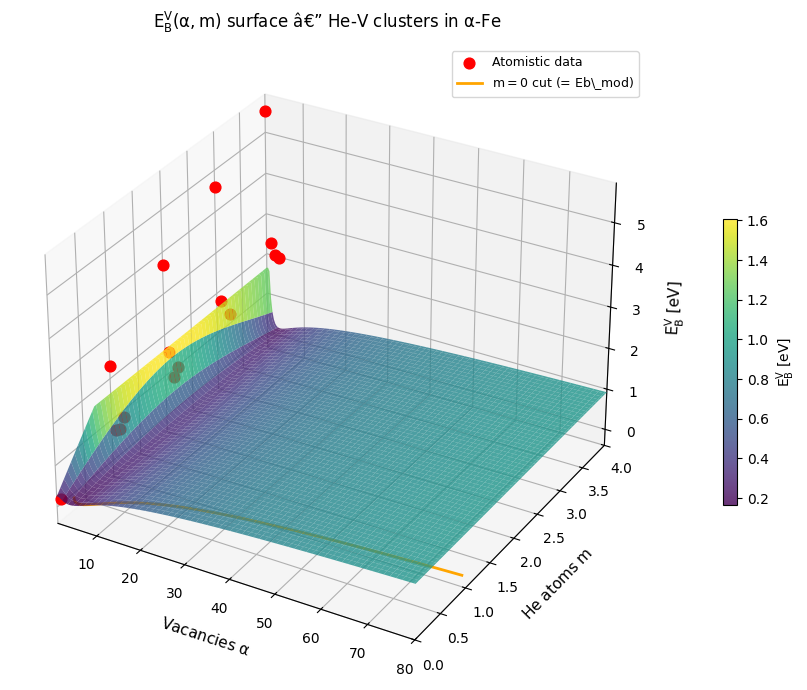

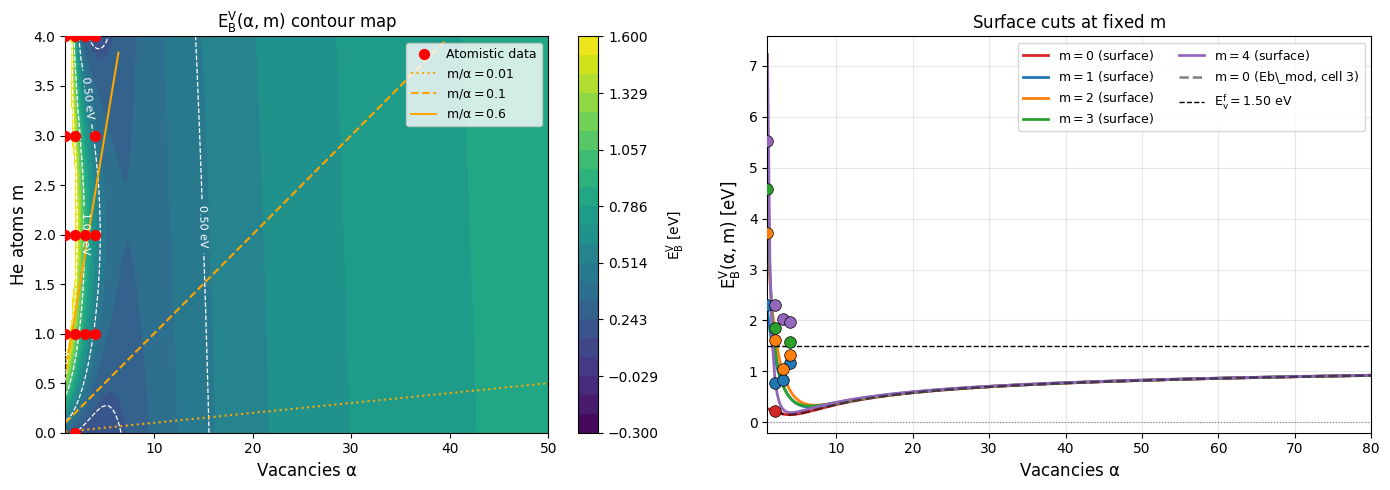

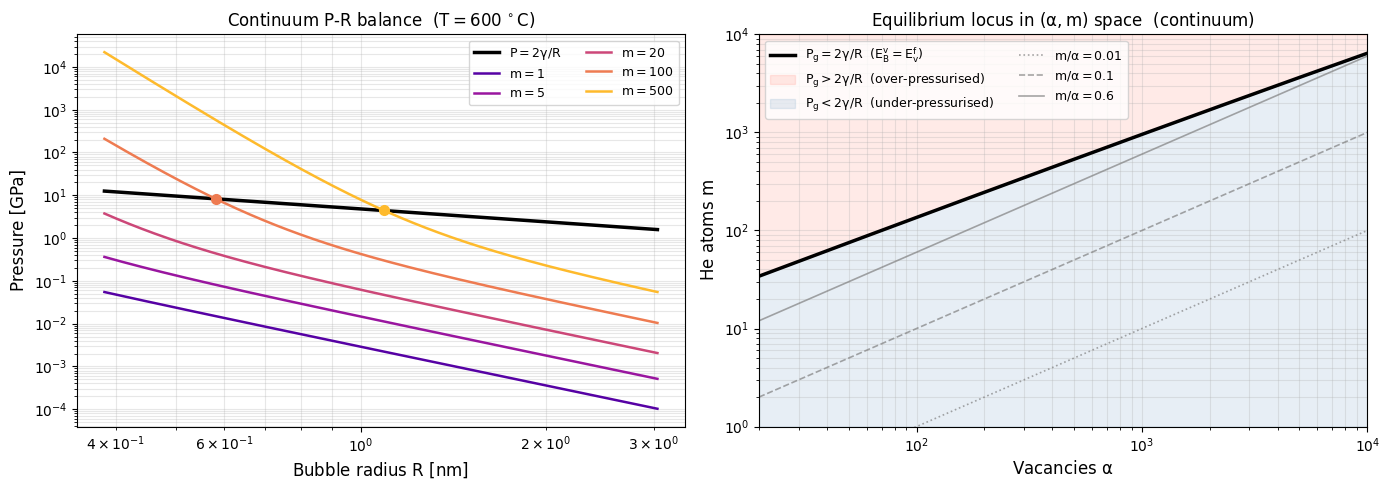

In [6]:
# -------------------------------------------------------
# 2D binding energy surface E_B^v(alpha, m) for He-V clusters in bcc Fe
#
# Model:
#   E_B^v(alpha, m) = Eb_cont(alpha, m) + A(m) * exp(-lambda * (alpha - 1))
#
#   Eb_cont(alpha, m)  â€” continuum capillarity + virial EOS (cells 3â€“4)
#   A(m)               â€” correction amplitude, fit by least-squares to data;
#                        cubic-spline interpolated for non-integer m
#   lambda = ln(100)/8 â€” same decay rate as pure-void correction (cell 3)
#
# Data sources:
#   m = 0:  Osetsky et al. (2000), J. Nucl. Mater. 276, 65
#   m >= 1: Caturla et al. (2008), as recast binding energies
#
# Guarantee: the m=0 cut of the surface equals Eb_mod from cell 3 exactly.
# -------------------------------------------------------

from scipy.interpolate import CubicSpline
from mpl_toolkits.mplot3d import Axes3D

# --- Atomistic data table: rows = (alpha, m, E_B^v [eV]) ---
data_am = np.array([
    [2, 0, 0.22],                                                 # Osetsky et al.
    [1, 1, 2.30], [2, 1, 0.78], [3, 1, 0.83], [4, 1, 1.16],     # Caturla et al.
    [1, 2, 3.71], [2, 2, 1.61], [3, 2, 1.04], [4, 2, 1.32],
    [1, 3, 4.59], [2, 3, 1.85],               [4, 3, 1.57],
    [1, 4, 5.52], [2, 4, 2.30], [3, 4, 2.03], [4, 4, 1.97],
])
alpha_d, m_d, Eb_d = data_am[:, 0], data_am[:, 1], data_am[:, 2]

# --- Vectorised continuum E_B^v(alpha, m): array alpha, scalar m ---
def Eb_cont_2d(alpha, m):
    alpha = np.asarray(alpha, dtype=float)
    R = a * (3.0 * alpha / (8.0 * np.pi))**(1.0 / 3.0)
    if m > 0:
        n_he = (float(m) / alpha) / Omega
        P_g  = n_he * kB * T_void * (1.0 + B_2 * n_he + B_3 * n_he**2)
    else:
        P_g = 0.0
    return E_F_v - Omega * (2.0 * gamma / R - P_g)

# --- Correction residuals delta = E_B^v_data - Eb_cont at each data point ---
delta_d = np.array([
    Eb_d[i] - float(Eb_cont_2d(alpha_d[i], m_d[i]))
    for i in range(len(Eb_d))
])

# --- Fit A(m) by least-squares at each integer m (fixed lambda) ---
# Model:  delta(alpha, m) = A(m) * exp(-lambda * (alpha - 1))
# Solution: A = (b^T delta) / (b^T b),  b_i = exp(-lambda*(alpha_i - 1))
m_uniq = np.unique(m_d)   # [0, 1, 2, 3, 4]
A_vals = np.zeros(len(m_uniq))

for k, m_val in enumerate(m_uniq):
    mask  = m_d == m_val
    a_m   = alpha_d[mask]
    del_m = delta_d[mask]
    basis = np.exp(-lam * (a_m - 1.0))
    A_vals[k] = np.dot(basis, del_m) / np.dot(basis, basis)

# Cubic spline A(m) for continuous m (clamped to zero slope at m=0)
cs_A = CubicSpline(m_uniq, A_vals, bc_type='not-a-knot', extrapolate=True)

# --- Full surface function ---
def Eb_surface(alpha, m):
    """
    Corrected 2D binding energy surface.
    Vectorised over alpha; scalar m.
    Reduces to Eb_mod (cell 3) at m=0.
    """
    alpha = np.asarray(alpha, dtype=float)
    return Eb_cont_2d(alpha, m) + float(cs_A(m)) * np.exp(-lam * (alpha - 1.0))

# --- Verify: m=0 cut must equal Eb_mod (cell 3) ---
# Proof: A(0) = delta(2,0)/exp(-lam*1)  =>  A(0)*exp(-lam*(a-1)) = delta(2,0)*exp(-lam*(a-2))
#        which is exactly the correction used in cell 3.
print("Verification â€” m=0 surface cut vs. Eb_mod (cell 3):")
print(f"  {'alpha':>6}  {'Surface':>10}  {'Eb_mod':>10}  {'diff':>9}")
for a_chk in [2, 3, 5, 10, 20, 50, 100, 200]:
    idx = int(a_chk) - 2          # alpha_v = arange(2, 1001)
    s   = float(Eb_surface(float(a_chk), 0.0))
    em  = Eb_mod[idx] if 0 <= idx < len(Eb_mod) else float('nan')
    print(f"  {a_chk:6d}  {s:10.4f}  {em:10.4f}  {s-em:9.1e}")

# --- Fit quality: residuals at atomistic data points ---
print(f"\nFit residuals  (E_B^v_surface - E_B^v_data):")
print(f"  {'(alpha,m)':>9}  {'data':>7}  {'surface':>9}  {'resid':>8}")
for i in range(len(Eb_d)):
    a_i, m_i, eb_i = alpha_d[i], m_d[i], Eb_d[i]
    pred = float(Eb_surface(a_i, m_i))
    print(f"  ({int(a_i):2d},{int(m_i):1d})     {eb_i:7.3f}  {pred:9.3f}  {pred-eb_i:8.3f}")

print(f"\nFitted amplitudes A(m):")
for m_i, A_i in zip(m_uniq, A_vals):
    print(f"  m = {m_i:.0f}: A = {A_i:.3f} eV")

# -------------------------------------------------------
# Plots
# -------------------------------------------------------
alpha_surf = np.linspace(1.0, 80.0, 250)
m_surf     = np.linspace(0.0, 4.0, 120)

# Build (alpha, m) grid
ALPHA, M_GRID = np.meshgrid(alpha_surf, m_surf, indexing='ij')   # (n_a, n_m)
Z = np.zeros_like(ALPHA)
for j, m_val in enumerate(m_surf):
    Z[:, j] = Eb_surface(alpha_surf, m_val)
Z_vis = np.clip(Z, -0.4, E_F_v + 0.15)

# â”€â”€â”€ Figure 1: 3D surface â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig3d = plt.figure(figsize=(10, 7))
ax3d  = fig3d.add_subplot(111, projection='3d')

surf3d = ax3d.plot_surface(ALPHA, M_GRID, Z_vis,
                            cmap='viridis', alpha=0.80,
                            linewidth=0, antialiased=True, rcount=80, ccount=80)

# Scatter atomistic data
ax3d.scatter(alpha_d, m_d, Eb_d,
             c='red', s=60, zorder=10, depthshade=False, label='Atomistic data')

# m=0 pure-void cut (Eb_mod, exact match)
ax3d.plot(alpha_v[:79], Eb_mod[:79], np.zeros(79),
          color='orange', linewidth=2, label=r'$m=0$ cut (= Eb\_mod)')

ax3d.set_xlabel(r'Vacancies $\alpha$',  fontsize=11, labelpad=8)
ax3d.set_ylabel(r'He atoms $m$',        fontsize=11, labelpad=8)
ax3d.set_zlabel(r'$E_B^V$ [eV]',        fontsize=11, labelpad=8)
ax3d.set_title(r'$E_B^V(\alpha,m)$ surface â€” He-V clusters in $\alpha$-Fe', pad=12)
ax3d.set_xlim(1, 80); ax3d.set_ylim(0, 4)
fig3d.colorbar(surf3d, ax=ax3d, shrink=0.45, pad=0.08, label='$E_B^V$ [eV]')
ax3d.legend(fontsize=9, loc='upper right')
plt.tight_layout()
fig3d.savefig(PLOT_DIR / 'Eb_surface_3D.png', dpi=150, bbox_inches='tight')
plt.show()

# â”€â”€â”€ Figure 2: contour map + cuts at fixed m â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: filled contour in (alpha, m) space ---
ax = axes[0]
levels_fill = np.linspace(-0.3, E_F_v + 0.1, 22)
levels_line = sorted(set([0.0, 0.22, 0.5, 1.0, 1.5, E_F_v]))
cf = ax.contourf(ALPHA, M_GRID, Z_vis, levels=levels_fill, cmap='viridis')
ct = ax.contour( ALPHA, M_GRID, Z_vis, levels=levels_line,
                 colors='white', linewidths=0.9, linestyles='--')
ax.clabel(ct, fmt='%.2f eV', fontsize=8, inline=True)

# Atomistic data
ax.scatter(alpha_d, m_d, c='red', s=50, zorder=5, label='Atomistic data')

# Lines of constant m/alpha ratio
for ratio, ls, label in zip([0.01, 0.1, 0.6],
                              [':', '--', '-'],
                              [r'$m/\alpha=0.01$', r'$m/\alpha=0.1$', r'$m/\alpha=0.6$']):
    m_line = ratio * alpha_surf
    mask   = m_line <= m_surf[-1]
    ax.plot(alpha_surf[mask], m_line[mask],
            color='orange', linestyle=ls, linewidth=1.5, label=label)

fig2.colorbar(cf, ax=ax, label='$E_B^V$ [eV]')
ax.set_xlabel(r'Vacancies $\alpha$', fontsize=12)
ax.set_ylabel(r'He atoms $m$',       fontsize=12)
ax.set_title(r'$E_B^V(\alpha,m)$ contour map', fontsize=12)
ax.set_xlim(1, 50); ax.set_ylim(0, 4)
ax.legend(fontsize=9, loc='upper right')

# --- Right: E_B^v vs alpha at fixed m (cuts through surface) ---
ax = axes[1]
cut_m      = [0, 1, 2, 3, 4]
cut_colors = ['C3', 'C0', 'C1', 'C2', 'C4']

for m_cut, col in zip(cut_m, cut_colors):
    Eb_cut = Eb_surface(alpha_surf, float(m_cut))
    ax.plot(alpha_surf, Eb_cut, color=col, linewidth=2,
            label=rf'$m={m_cut}$ (surface)')
    # Atomistic data for this m
    mask = m_d == m_cut
    if np.any(mask):
        ax.scatter(alpha_d[mask], Eb_d[mask],
                   color=col, s=70, zorder=5, edgecolors='k', linewidths=0.5)

# Pure-void reference: Eb_mod from cell 3 (dashed; should overlap m=0 surface)
ax.plot(alpha_v[:199], Eb_mod[:199], 'k--', linewidth=1.8, alpha=0.5,
        label=r'$m=0$ (Eb\_mod, cell 3)')

ax.axhline(E_F_v, color='k', linestyle='--', linewidth=1,
           label=rf'$E_v^f = {E_F_v:.2f}$ eV')
ax.axhline(0.0, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel(r'Vacancies $\alpha$',       fontsize=12)
ax.set_ylabel(r'$E_B^V(\alpha,m)$ [eV]',  fontsize=12)
ax.set_title(r'Surface cuts at fixed $m$', fontsize=12)
ax.set_xlim(1, 80)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig2.savefig(PLOT_DIR / 'Eb_surface_contours.png', dpi=150, bbox_inches='tight')
plt.show()
# --- Figure 3: Continuum limit -- P = 2*gamma/R thermodynamic equilibrium ---
# In the large-alpha,m (continuum) regime the discrete correction vanishes and
#   E_B^v_cont(alpha, m) = E_v^f   iff   P_g(alpha, m) = 2*gamma/R(alpha)
# This is the classical capillary-equilibrium condition.
# ---------------------------------------------------------------------------

from scipy.optimize import brentq

eV_to_GPa = 1.602176634e-19 * 1e-9   # [eV/m^3] -> [GPa]
kBT_void  = kB * T_void               # eV

# Continuum alpha range (alpha >= 20; correction < 1%)
alpha_c = np.logspace(np.log10(20), 4, 400)
R_c     = a * (3.0 * alpha_c / (8.0 * np.pi))**(1.0/3.0)   # m
R_c_nm  = R_c * 1e9                                          # nm
P_cap_c = 2.0 * gamma / R_c                                  # eV/m^3

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

# -- Left panel: P vs R (log-log) ------------------------------------------
ax = axes3[0]

ax.loglog(R_c_nm, P_cap_c * eV_to_GPa, 'k-', linewidth=2.5,
          label=r'$P = 2\gamma/R$')

m_list = [1, 5, 20, 100, 500]
cmap_c = plt.cm.plasma(np.linspace(0.15, 0.85, len(m_list)))

for m_val, col in zip(m_list, cmap_c):
    n_he = m_val / (alpha_c * Omega)
    P_g  = n_he * kBT_void * (1.0 + B_2 * n_he + B_3 * n_he**2)   # eV/m^3
    ax.loglog(R_c_nm, P_g * eV_to_GPa, color=col, linewidth=1.8,
              label=rf'$m = {m_val}$')
    diff = P_g - P_cap_c
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    for idx in sign_changes:
        R_eq = 0.5 * (R_c_nm[idx] + R_c_nm[idx + 1])
        P_eq = 0.5 * (P_g[idx] + P_g[idx + 1]) * eV_to_GPa
        ax.plot(R_eq, P_eq, 'o', color=col, markersize=7, zorder=5)

ax.set_xlabel(r'Bubble radius $R$ [nm]', fontsize=12)
ax.set_ylabel(r'Pressure [GPa]',          fontsize=12)
ax.set_title(r'Continuum $P$-$R$ balance  ($T = 600\,^\circ\mathrm{C}$)', fontsize=12)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which='both', alpha=0.3)

# -- Right panel: equilibrium locus m_eq(alpha) ----------------------------
ax = axes3[1]

def _n_he_eq(P_c_eV):
    f    = lambda x: x * kBT_void * (1.0 + B_2 * x + B_3 * x**2) - P_c_eV
    x_hi = (P_c_eV / kBT_void) * 10.0
    try:
        return brentq(f, 0.0, x_hi, xtol=1e-30, rtol=1e-10)
    except ValueError:
        return np.nan

m_eq = np.array([_n_he_eq(Pc) * Omega * ai
                 for Pc, ai in zip(P_cap_c, alpha_c)])

ax.loglog(alpha_c, m_eq, 'k-', linewidth=2.5,
          label=r'$P_g = 2\gamma/R$  ($E_B^v = E_v^f$)')

ax.fill_between(alpha_c, m_eq, np.full_like(alpha_c, 1e4),
                color='tomato',    alpha=0.13,
                label=r'$P_g > 2\gamma/R$  (over-pressurised)')
ax.fill_between(alpha_c, np.full_like(alpha_c, 1.0), m_eq,
                color='steelblue', alpha=0.13,
                label=r'$P_g < 2\gamma/R$  (under-pressurised)')

for ratio, ls, lbl in zip([0.01, 0.1, 0.6], [':', '--', '-'],
                            [r'$m/\alpha=0.01$', r'$m/\alpha=0.1$', r'$m/\alpha=0.6$']):
    ax.loglog(alpha_c, ratio * alpha_c,
              color='grey', linestyle=ls, linewidth=1.2, alpha=0.7, label=lbl)

ax.set_xlabel(r'Vacancies $\alpha$', fontsize=12)
ax.set_ylabel(r'He atoms $m$',        fontsize=12)
ax.set_title(r'Equilibrium locus in $(\alpha,m)$ space  (continuum)', fontsize=12)
ax.set_xlim(alpha_c[0], alpha_c[-1])
ax.set_ylim(1.0, 1e4)
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
fig3.savefig(PLOT_DIR / 'Eb_continuum_equilibrium.png', dpi=150, bbox_inches='tight')
plt.show()


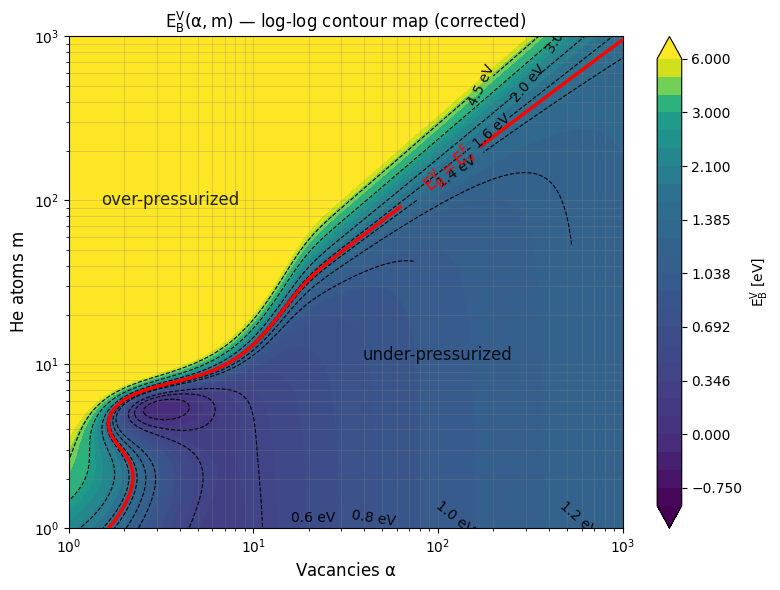

In [7]:
# -------------------------------------------------------
# Log-log contour plot: E_B^v(alpha, m) in (alpha, m) space
# x-axis: alpha (vacancies),  y-axis: m (He atoms)
# Both axes log-scaled; uses corrected Eb_surface from cell 4.
#
# Non-uniform contour levels: dense near 0..E_v^F (physically
# interesting range) and sparser above, so contours spread across
# the full (alpha, m) space rather than clustering near small alpha.
# -------------------------------------------------------

alpha_ll = np.logspace(-0.1, 3.1, 440)   # alpha: slightly beyond [1, 1000] so contours close at boundaries
m_ll     = np.logspace(-0.1, 3.1, 440)   # m:     slightly beyond [1, 1000]

ALPHA_LL, M_LL = np.meshgrid(alpha_ll, m_ll, indexing='ij')
Z_ll = np.zeros_like(ALPHA_LL)
for j, m_val in enumerate(m_ll):
    Z_ll[:, j] = Eb_surface(alpha_ll, m_val)

# --- Non-uniform fill levels: concentrated in the physically relevant
#     range, expanding sparsely into the high-pressure / small-alpha regime ---
levels_fill = np.concatenate([
    np.linspace(-1.0,    0.0,    5),   # negative (under-bound)
    np.linspace( 0.0,    E_F_v, 14),   # 0 .. E_v^F  (main physics window)
    np.linspace( E_F_v,  3.0,   6),    # E_v^F .. 3 eV
    np.linspace( 3.0,    6.0,   4),    # 3 .. 6 eV (high-pressure corner)
])
levels_fill = np.unique(levels_fill)

# --- Non-uniform line contours at physically meaningful values ---
levels_line = [-0.5, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 2.0, 3.0, 4.5]
levels_line = [l for l in levels_line if abs(l - E_F_v) > 0.08]   # avoid overlap with red

fig_ll, ax_ll = plt.subplots(figsize=(8, 6))

cf = ax_ll.contourf(ALPHA_LL, M_LL, Z_ll,
                    levels=levels_fill, cmap='viridis', extend='both')

ct = ax_ll.contour(ALPHA_LL, M_LL, Z_ll,
                   levels=levels_line,
                   colors='black', linewidths=0.8, linestyles='--', alpha=0.95)
ax_ll.clabel(ct, fmt='%.1f eV', fontsize=10, inline=True, inline_spacing=8)

# --- Thick red line at E_B^V = E_v^F (emission threshold) ---
ct_red = ax_ll.contour(ALPHA_LL, M_LL, Z_ll,
                       levels=[E_F_v],
                       colors='red', linewidths=2.5)
ax_ll.clabel(ct_red, fmt=r'$E_B^V = E_v^F$',
             fontsize=12, manual=[(150, 100)], inline=True)

# --- Region labels ---
ax_ll.text(1.5,  100, 'over-pressurized',
           fontsize=12, color='black', ha='left', va='center', style='italic', alpha=0.85)
ax_ll.text(100,  10, 'under-pressurized',
           fontsize=12, color='black', ha='center', va='bottom', style='italic', alpha=0.85)

fig_ll.colorbar(cf, ax=ax_ll, label=r'$E_B^V$ [eV]', extend='both')
ax_ll.set_xscale('log')
ax_ll.set_yscale('log')
ax_ll.set_xlabel(r'Vacancies $\alpha$', fontsize=12)
ax_ll.set_ylabel(r'He atoms $m$',       fontsize=12)
ax_ll.set_title(r'$E_B^V(\alpha,m)$ — log-log contour map (corrected)', fontsize=12)
ax_ll.set_xlim(1, 1000)
ax_ll.set_ylim(1, 1000)
ax_ll.grid(True, which='both', alpha=0.25, color='gray')

plt.tight_layout()
fig_ll.savefig(PLOT_DIR / 'Eb_loglog_contour.png', dpi=150, bbox_inches='tight')
plt.show()


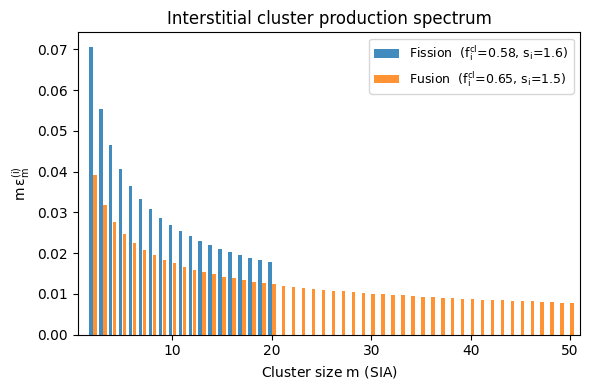

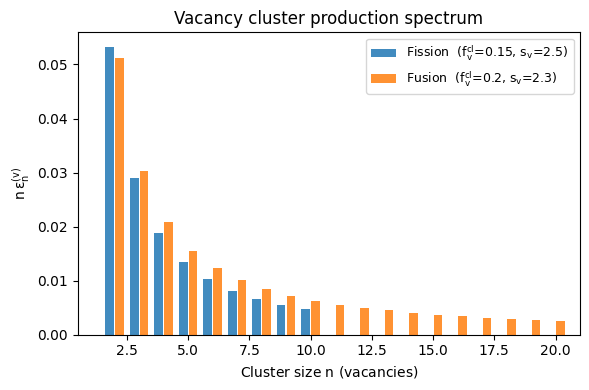

In [8]:
# -------------------------------------------------------
# Defect cluster production spectra: fission vs fusion
# Calls defect_production.py (no side effects at import)
# -------------------------------------------------------
import sys
sys.path.insert(0, "../../EuroferExperiments/py_utils")
from defect_production import fission, fusion, get_cluster_spectra

m_f, ei_f, n_f, ev_f = get_cluster_spectra(fission)
m_u, ei_u, n_u, ev_u = get_cluster_spectra(fusion)

# --- Interstitial cluster spectra ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(m_f - 0.2, m_f * ei_f, width=0.35, color='C0', alpha=0.85,
       label=f"Fission  ($f_i^{{\\rm cl}}$={fission['f_i_cl']}, $s_i$={fission['s_i']})")
ax.bar(m_u + 0.2, m_u * ei_u, width=0.35, color='C1', alpha=0.85,
       label=f"Fusion  ($f_i^{{\\rm cl}}$={fusion['f_i_cl']}, $s_i$={fusion['s_i']})")
ax.set_xlabel(r"Cluster size $m$ (SIA)")
ax.set_ylabel(r"$m\,\varepsilon_m^{(i)}$")
ax.set_title("Interstitial cluster production spectrum")
ax.legend(fontsize=9)
ax.set_xlim(0.5, max(m_u[-1], m_f[-1]) + 1)
fig.tight_layout()
fig.savefig(PLOT_DIR / "interstitial_cluster_spectrum.png", dpi=150)
plt.show()

# --- Vacancy cluster spectra ---
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.bar(n_f - 0.2, n_f * ev_f, width=0.35, color='C0', alpha=0.85,
        label=f"Fission  ($f_v^{{\\rm cl}}$={fission['f_v_cl']}, $s_v$={fission['s_v']})")
ax2.bar(n_u + 0.2, n_u * ev_u, width=0.35, color='C1', alpha=0.85,
        label=f"Fusion  ($f_v^{{\\rm cl}}$={fusion['f_v_cl']}, $s_v$={fusion['s_v']})")
ax2.set_xlabel(r"Cluster size $n$ (vacancies)")
ax2.set_ylabel(r"$n\,\varepsilon_n^{(v)}$")
ax2.set_title("Vacancy cluster production spectrum")
ax2.legend(fontsize=9)
ax2.set_xlim(0.5, max(n_u[-1], n_f[-1]) + 1)
fig2.tight_layout()
fig2.savefig(PLOT_DIR / "vacancy_cluster_spectrum.png", dpi=150)
plt.show()